In [11]:
from zipfile import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd

num_samples_sweep = [128, 256, 512, 1024, 2048, 4096]
num_randomizations_sweep = [1, 2, 4, 8, 16, 32]

algos = ["mppi", "cem", "mtp", "anmtp"]


#### Sample Sweeps

In [12]:
data = {
    "algorithm": algos * 6,
    "t_sample_sweep": [],
    "t_domain_sweep": [],
}

for algo in algos:
    path = f"./scaling_data_samples/{algo}.pkl"
    with open(path, "rb") as f:
        algo_data = pickle.load(f)
        
    data["t_sample_sweep"].extend(algo_data[:, 0, -1].tolist())
    data["t_domain_sweep"].extend(algo_data[0, :, -1].tolist())
    

FileNotFoundError: [Errno 2] No such file or directory: './scaling_data_samples/cem.pkl'

#### Horizon Sweeps

<Axes: xlabel='mppi'>

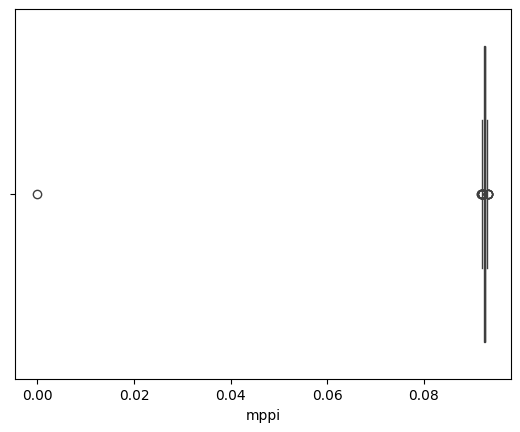

In [9]:
path = "./scaling_data_samples/mppi.pkl"
with open(path, "rb") as f:
    data = pickle.load(f)
print(data.shape)  # (num_samples_sweep, num_randomizations_sweep, max_step-1)

df = pd.DataFrame()
df["mppi"] = data[0,0,:]

sns.boxplot(x=df["mppi"])

In [5]:
# Compute mean and std across first two dimensions
mean = data.mean(axis=(2))  # shape (steps,)
std  = data.std(axis=(2))   # shape (steps,)

print(mean.shape, std.shape)


(1, 1) (1, 1)


In [5]:
# plot over first dimension (steps)
time = np.arange(mean.shape[0])


In [ ]:
# plot over second dimension assuming first dimension is steps
plt.figure(figsize=(10, 6))
